# GARCH 模型：上证综指波动率建模

本 Notebook 对上证综指日对数收益率拟合 GARCH 模型，
刻画波动率聚集现象并进行样本外波动率预测。

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.plot_config

from src.data_loader import load_train, load_test
from src.preprocess import preprocess
from src.eda import check_stationarity
from src.garch_model import (
    prepare_returns, search_garch_order, fit_garch,
    garch_diagnostics, rolling_forecast_garch
)

import warnings
warnings.filterwarnings('ignore')

FIGURES = ROOT / 'outputs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. 数据准备

加载并预处理训练数据，提取对数收益率序列，
并通过 ADF 检验验证其平稳性。

In [2]:
raw_train = load_train()
df_train = preprocess(raw_train)
print(f'训练集: {df_train.index.min().date()} ~ {df_train.index.max().date()}, {len(df_train)} 条')

returns = df_train['log_return']
print(f'\n收益率序列长度: {len(returns)}')
returns.describe()

训练集: 2016-01-05 ~ 2020-12-31, 1217 条

收益率序列长度: 1217


count    1217.000000
mean        0.000043
std         0.011701
min        -0.080392
25%        -0.004921
50%         0.000579
75%         0.005348
max         0.055542
Name: log_return, dtype: float64

In [3]:
adf_result = check_stationarity(returns)
display(adf_result)
if adf_result['is_stationary'].iloc[0]:
    print('✓ 对数收益率序列平稳，可以直接进行 GARCH 建模')
else:
    print('✗ 序列非平稳，请检查数据')

,adf_statistic,p_value,critical_1%,critical_5%,critical_10%,is_stationary
log_return,-15.992226,6.651586e-29,-3.435761,-2.86393,-2.568042,True


✓ 对数收益率序列平稳，可以直接进行 GARCH 建模


## 2. 波动率聚集观察

绘制收益率和收益率平方（波动率代理指标），
直观观察波动率聚集现象：高波动率时期往往连续出现。

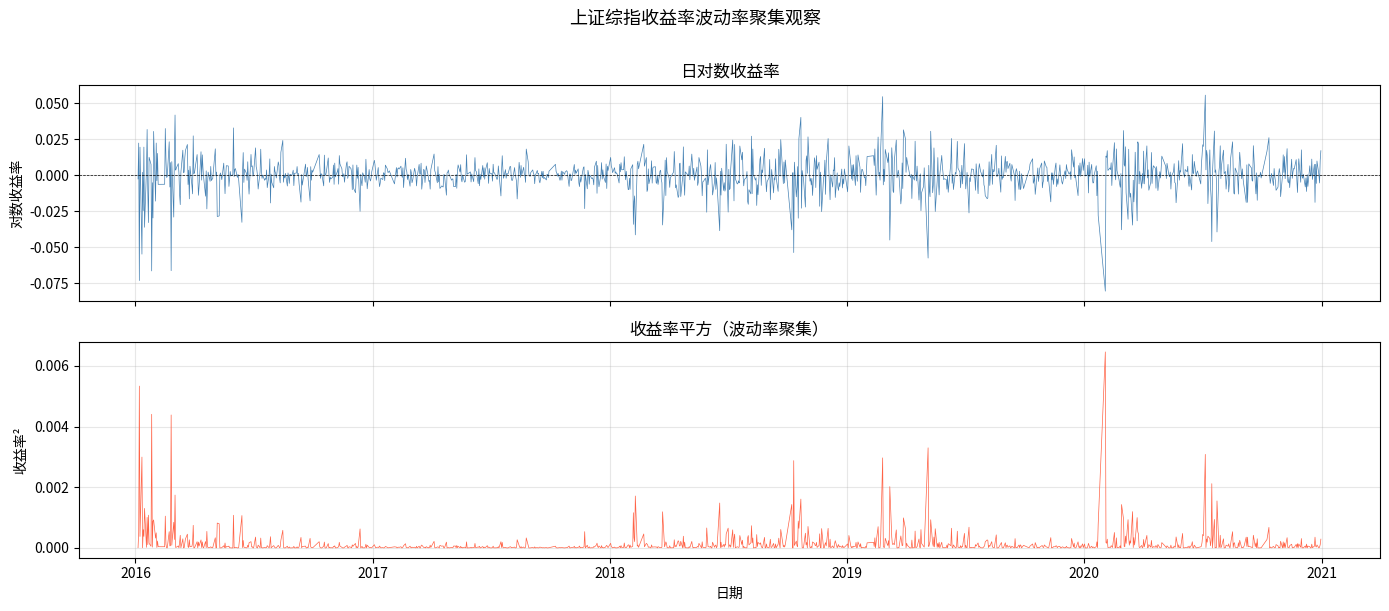

观察：收益率在某些时段（如 2008 年金融危机、2015 年股灾）呈现明显的波动率聚集现象，
这正是 GARCH 模型的适用场景。


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(returns.index, returns.values, linewidth=0.5, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('日对数收益率')
axes[0].set_ylabel('对数收益率')
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns.index, returns.values ** 2, linewidth=0.5, color='tomato')
axes[1].set_title('收益率平方（波动率聚集）')
axes[1].set_ylabel('收益率²')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

fig.suptitle('上证综指收益率波动率聚集观察', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_volatility_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('观察：收益率在某些时段（如 2008 年金融危机、2015 年股灾）呈现明显的波动率聚集现象，')
print('这正是 GARCH 模型的适用场景。')

## 3. ARCH 效应检验

对收益率平方进行 Ljung-Box 检验，验证是否存在显著的 ARCH 效应。
p < 0.05 说明存在显著自相关，即 ARCH 效应。

In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_sq = acorr_ljungbox(returns ** 2, lags=10, return_df=True)
display(lb_sq)

if (lb_sq['lb_pvalue'] < 0.05).any():
    print('✓ 检测到显著 ARCH 效应（收益率平方存在自相关），GARCH 建模适用')
else:
    print('✗ 未检测到显著 ARCH 效应，GARCH 建模可能不适用')

,lb_stat,lb_pvalue
1,5.005636,2.526492e-02
2,31.910971,1.176578e-07
3,44.443885,1.214620e-09
4,57.509090,9.674158e-12
5,63.923182,1.874053e-12
6,71.684273,1.844749e-13
7,83.477226,2.685805e-15
8,92.712345,1.307186e-16
9,98.562434,3.072426e-17
10,113.292261,1.154967e-19


✓ 检测到显著 ARCH 效应（收益率平方存在自相关），GARCH 建模适用


In [6]:
# 使用 prepare_returns 进行完整校验
returns_clean = prepare_returns(returns)
print(f'清洗后收益率序列长度: {len(returns_clean)}')

清洗后收益率序列长度: 1217


## 4. 参数搜索

对 GARCH(p, q) 进行网格搜索（p, q ∈ {1, 2}），
以 AIC 为准则选出最优规格。

In [7]:
order_df = search_garch_order(
    returns_clean,
    p_range=(1, 2),
    q_range=(1, 2),
    criterion='aic'
)
print('GARCH 阶次搜索结果（按 AIC 排序）：')
display(order_df)

GARCH 阶次搜索结果（按 AIC 排序）：


,p,q,aic,bic,converged
0,1,2,-7697.871117,-7672.350397,True
1,1,1,-7691.613318,-7671.196741,True
2,2,2,-7677.324838,-7646.699973,True
3,2,1,-7676.309922,-7650.789201,True


In [8]:
best_p = int(order_df.iloc[0]['p'])
best_q = int(order_df.iloc[0]['q'])
best_garch_order = (best_p, best_q)
print(f'最优阶次（AIC 最小）: GARCH{best_garch_order}')

最优阶次（AIC 最小）: GARCH(1, 2)


## 5. 模型拟合与样本外预测

调用 `rolling_forecast_garch`，同时完成：
- 在完整训练集上拟合 GARCH 模型（返回 `result`，供后续诊断使用）
- 对测试期逐步滚动预测 1 步条件波动率

滚动窗口 = 训练集长度（固定窗口，不扩张）。
无需单独调用 `fit_garch`。

In [9]:
# 加载测试集
raw_test = load_test()
df_test = preprocess(raw_test)
returns_test = df_test['log_return']
print(f'测试集: {df_test.index.min().date()} ~ {df_test.index.max().date()}, {len(df_test)} 条')

# 用 rolling_forecast_garch 同时完成模型拟合与样本外预测
# 返回 (rolling_df, result): result 为首次在全量训练集上的拟合结果
print(f'使用 GARCH{best_garch_order}，滚动窗口 = {len(returns_clean)}，逐步重新拟合...')
rolling_df, result = rolling_forecast_garch(
    train_data=returns_clean,
    test_data=returns_test,
    order=best_garch_order,
    dist='t',
    model_type='garch',
    refit_every=1,
)
print('滚动预测完成，样本外前 5 行：')
display(rolling_df.head())
print()
print(result.summary())

测试集: 2021-01-05 ~ 2025-12-31, 1211 条
使用 GARCH(1, 2)，滚动窗口 = 1217，逐步重新拟合...


滚动预测完成，样本外前 5 行：


,predicted_variance,predicted_volatility,realized_return
date,,,
2021-01-05,0.000089,0.009445,0.007315
2021-01-06,0.000087,0.009336,0.006272
2021-01-07,0.000085,0.009208,0.007108
2021-01-08,0.000082,0.009080,-0.001706
2021-01-11,0.000079,0.008887,-0.010874



                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1668.90
Distribution:      Standardized Student's t   AIC:                           3349.80
Method:                  Maximum Likelihood   BIC:                           3380.42
                                              No. Observations:                 1217
Date:                      Wed, Apr 08 2026   Df Residuals:                     1216
Time:                              17:37:59   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu 

In [10]:
# 提取关键参数
params = result.params
alpha_sum = sum(v for k, v in params.items() if k.startswith('alpha'))
beta_sum = sum(v for k, v in params.items() if k.startswith('beta'))
persistence = alpha_sum + beta_sum
print(f'\nα 之和: {alpha_sum:.4f}')
print(f'β 之和: {beta_sum:.4f}')
print(f'波动率持久性 (α+β): {persistence:.4f}')
if persistence < 1:
    print('→ 模型协方差平稳（持久性 < 1）')
else:
    print('→ 波动率持久性较高，考虑 IGARCH')


α 之和: 0.0526
β 之和: 0.9372
波动率持久性 (α+β): 0.9898
→ 模型协方差平稳（持久性 < 1）


## 6. 残差诊断

对标准化残差进行诊断，检验 GARCH 模型是否充分捕获了波动率结构：
- 标准化残差 ACF 不应显著
- 标准化残差平方 ACF 不应显著（无剩余 ARCH 效应）

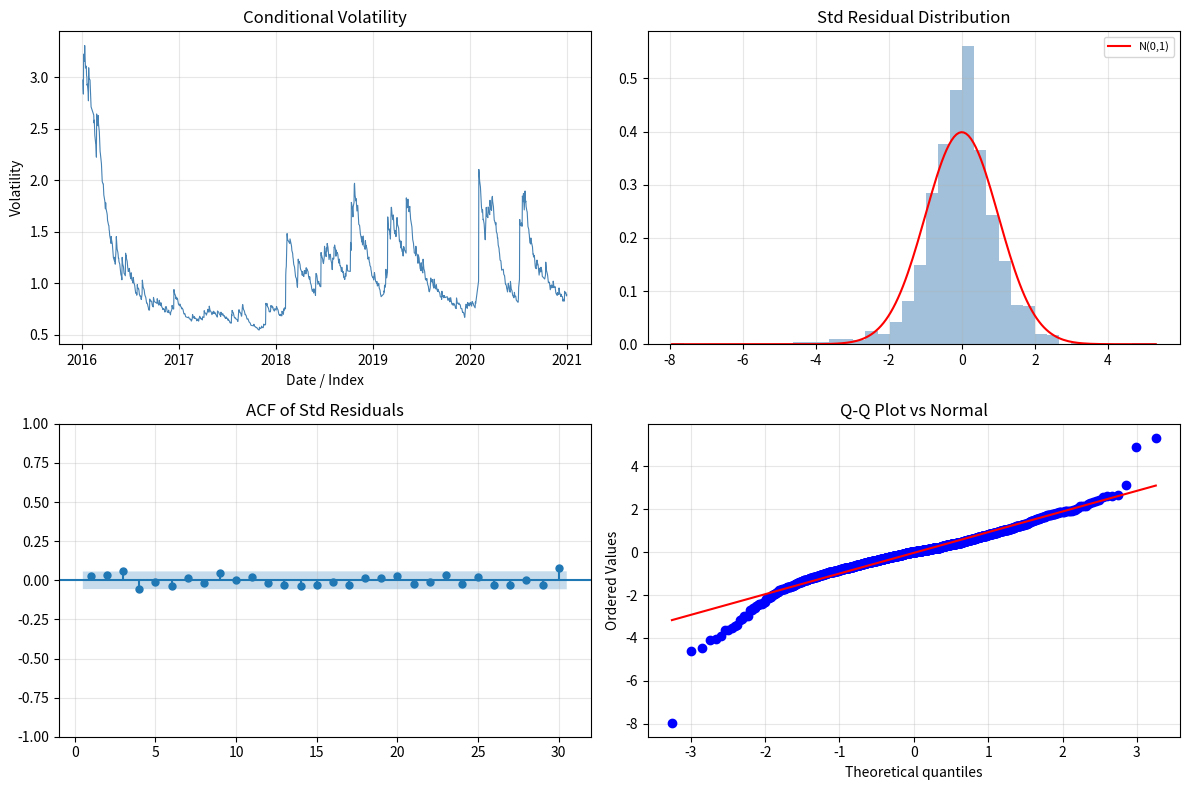

标准化残差统计：


mean       -0.034186
std         0.990934
skew       -0.688241
kurtosis    5.870300
Name: std_residual_stats, dtype: float64

In [11]:
diag = garch_diagnostics(
    result,
    lags=20,
    save_path=FIGURES / 'garch_residual_diagnostics.png'
)
plt.show()

print('标准化残差统计：')
display(diag['summary_stats'])

In [12]:
lb_resid = diag['ljung_box']
lb_resid_sq = diag['ljung_box_sq']

print('标准化残差 Ljung-Box 检验（前 5 滞后）：')
display(lb_resid.head(5))

print('\n标准化残差平方 Ljung-Box 检验（前 5 滞后）：')
display(lb_resid_sq.head(5))

if (lb_resid_sq['lb_pvalue'] > 0.05).all():
    print('\n✓ 标准化残差平方无显著自相关，GARCH 模型已充分捕获波动率聚集')
else:
    print('\n✗ 仍存在剩余 ARCH 效应，考虑提高 GARCH 阶次或换用非对称模型（GJR-GARCH）')

标准化残差 Ljung-Box 检验（前 5 滞后）：


,lb_stat,lb_pvalue
1,0.857284,0.354500
2,2.441433,0.295019
3,6.584481,0.086390
4,10.722104,0.029871
5,10.865198,0.054119



标准化残差平方 Ljung-Box 检验（前 5 滞后）：


,lb_stat,lb_pvalue
1,6.356313,0.011696
2,6.376164,0.041251
3,8.953981,0.029909
4,9.211888,0.056016
5,9.218125,0.100674



✗ 仍存在剩余 ARCH 效应，考虑提高 GARCH 阶次或换用非对称模型（GJR-GARCH）


## 7. GJR-GARCH 对比分析

第 6 节诊断显示 GARCH(1,2) 标准化残差平方在滞后 1–3 仍有显著自相关，说明对称 GARCH 未能完全捕获波动聚集。

**GJR-GARCH**（Glosten-Jagannathan-Runkle，1993）在 GARCH 基础上引入非对称项：

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \gamma \varepsilon_{t-1}^2 \mathbf{1}[\varepsilon_{t-1}<0] + \beta \sigma_{t-1}^2$$

当 $\gamma > 0$ 时，负向冲击对波动率的放大效果强于正向冲击（**杠杆效应**）。

本节对比 GARCH(1,2) 与 GJR-GARCH(1,2)，评估：信息准则、参数估计、残差诊断、条件波动率。

In [13]:
import warnings
warnings.filterwarnings('ignore')

# 使用相同阶次 (p,q) = best_garch_order 对两模型进行公平比较
res_garch = fit_garch(returns_clean, order=best_garch_order, model_type='garch', dist='t')
res_gjr   = fit_garch(returns_clean, order=best_garch_order, model_type='gjr',   dist='t')

compare_df = pd.DataFrame({
    'Log-Likelihood': [res_garch.loglikelihood, res_gjr.loglikelihood],
    'AIC':            [res_garch.aic,           res_gjr.aic],
    'BIC':            [res_garch.bic,           res_gjr.bic],
    'Num Params':     [len(res_garch.params),   len(res_gjr.params)],
}, index=[f'GARCH{best_garch_order}', f'GJR-GARCH{best_garch_order}'])

print('模型信息准则对比：')
display(compare_df.round(2))

aic_diff = res_garch.aic - res_gjr.aic
print(f'\nΔAIC (GARCH − GJR-GARCH) = {aic_diff:.2f}')
if aic_diff > 10:
    print('→ GJR-GARCH 显著更优（ΔAIC > 10）')
elif aic_diff > 0:
    print('→ GJR-GARCH 略优')
else:
    print('→ GARCH 更优，非对称项未能改善拟合')

模型信息准则对比：


,Log-Likelihood,AIC,BIC,Num Params
"GARCH(1, 2)",2751.62,-5491.24,-5460.61,6
"GJR-GARCH(1, 2)",2855.36,-5696.72,-5660.99,7



ΔAIC (GARCH − GJR-GARCH) = 205.48
→ GJR-GARCH 显著更优（ΔAIC > 10）


In [14]:
# 杠杆效应参数分析
gjr_params = res_gjr.params
alpha1 = gjr_params.get('alpha[1]', gjr_params.get('alpha', 0.0))
gamma1 = gjr_params.get('gamma[1]', gjr_params.get('gamma', 0.0))
betas  = sum(v for k, v in gjr_params.items() if k.startswith('beta'))
persistence_gjr = alpha1 + gamma1 / 2 + betas

print('GJR-GARCH 关键参数估计：')
param_df = pd.DataFrame({
    'Estimate': res_gjr.params,
    'Std Err':  res_gjr.std_err,
    't-stat':   res_gjr.params / res_gjr.std_err,
})
display(param_df.round(6))

print(f'\n杠杆效应系数 γ  = {gamma1:.4f}')
print(f'正向冲击响应 α  = {alpha1:.4f}')
print(f'负向冲击响应 α+γ = {alpha1 + gamma1:.4f}')
print(f'波动率持久性 (α + γ/2 + β) = {persistence_gjr:.4f}')
if gamma1 > 0.01:
    print('\n→ γ > 0：存在杠杆效应，负向冲击对波动率的放大程度强于正向冲击')
else:
    print('\n→ γ 接近 0：杠杆效应不显著')

GJR-GARCH 关键参数估计：


,Estimate,Std Err,t-stat
mu,0.000085,0.000291,0.293060
omega,0.000909,0.000022,41.086868
alpha[1],0.650048,0.225878,2.877877
gamma[1],0.017475,0.120505,0.145010
beta[1],0.250702,0.224326,1.117577
beta[2],0.037616,0.222282,0.169226
nu,30.501595,0.177199,172.131897



杠杆效应系数 γ  = 0.0175
正向冲击响应 α  = 0.6500
负向冲击响应 α+γ = 0.6675
波动率持久性 (α + γ/2 + β) = 0.9471

→ γ > 0：存在杠杆效应，负向冲击对波动率的放大程度强于正向冲击


--- GARCH 残差诊断 ---


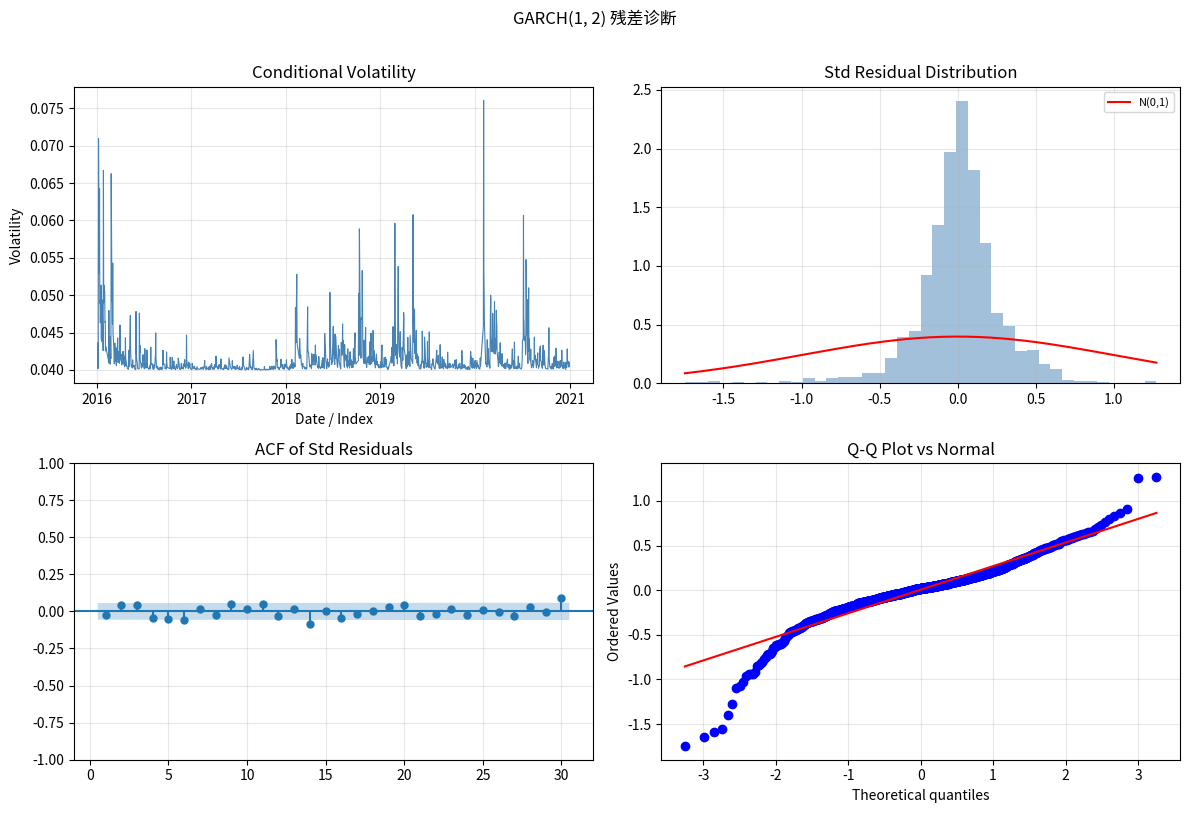

--- GJR-GARCH 残差诊断 ---


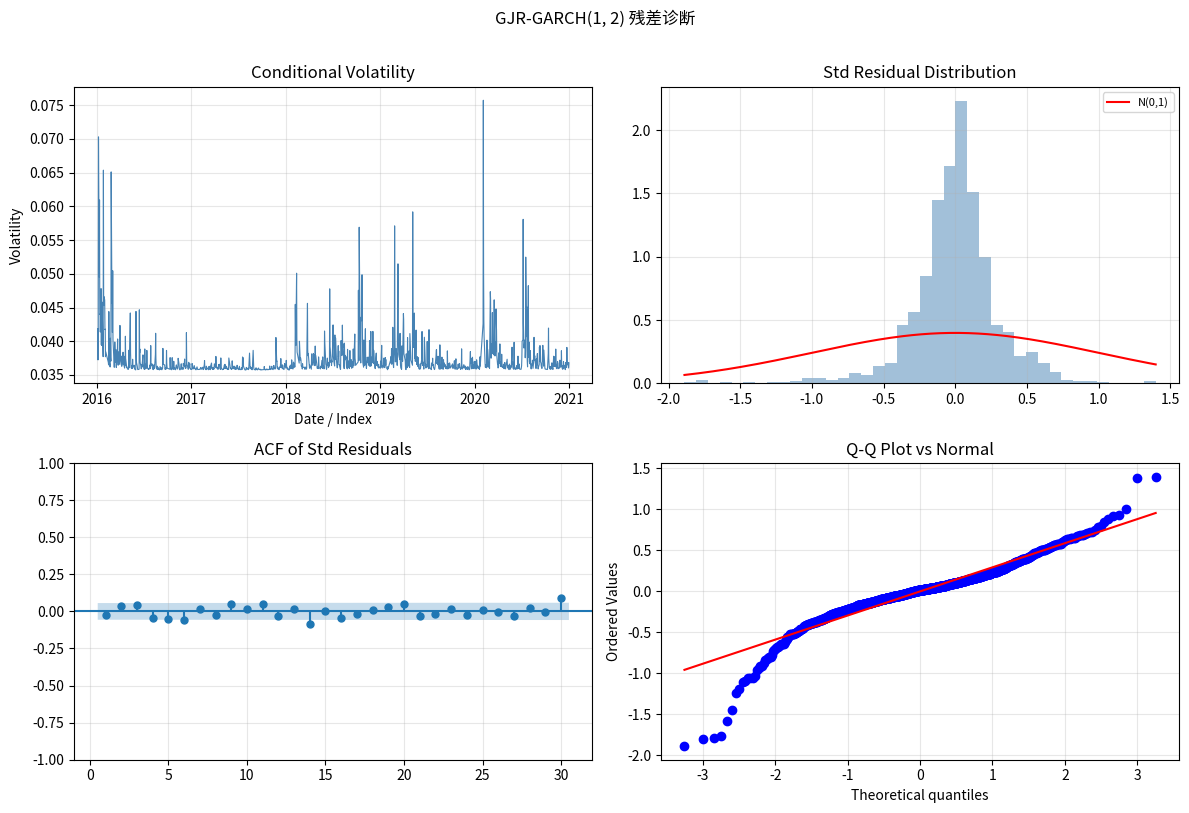

标准化残差平方 Ljung-Box p 值对比（p < 0.05 表示仍有 ARCH 效应）：


,"GARCH(1, 2)","GJR-GARCH(1, 2)"
Lag,,
1,0.2483,0.3827
2,0.0019,0.0051
3,0.0000,0.0001
4,0.0000,0.0000
5,0.0000,0.0000
6,0.0000,0.0000
7,0.0000,0.0000
8,0.0000,0.0000
9,0.0000,0.0000



GARCH:     前 10 滞后中 9/10 显著
GJR-GARCH: 前 10 滞后中 9/10 显著


In [15]:
# 残差诊断对比：GARCH vs GJR-GARCH
print('--- GARCH 残差诊断 ---')
diag_garch2 = garch_diagnostics(res_garch, lags=20)
plt.suptitle(f'GARCH{best_garch_order} 残差诊断', y=1.01)
plt.tight_layout()
plt.show()

print('--- GJR-GARCH 残差诊断 ---')
diag_gjr = garch_diagnostics(res_gjr, lags=20,
                             save_path=FIGURES / 'gjr_garch_residual_diagnostics.png')
plt.suptitle(f'GJR-GARCH{best_garch_order} 残差诊断', y=1.01)
plt.tight_layout()
plt.show()

# 标准化残差平方 Ljung-Box 对比
lb_sq_g   = diag_garch2['ljung_box_sq']
lb_sq_gjr = diag_gjr['ljung_box_sq']

compare_lb = pd.DataFrame({
    f'GARCH{best_garch_order}':     lb_sq_g['lb_pvalue'].values[:10],
    f'GJR-GARCH{best_garch_order}': lb_sq_gjr['lb_pvalue'].values[:10],
}, index=range(1, 11))
compare_lb.index.name = 'Lag'

print('标准化残差平方 Ljung-Box p 值对比（p < 0.05 表示仍有 ARCH 效应）：')
display(compare_lb.round(4))

sig_g   = (lb_sq_g['lb_pvalue'][:10] < 0.05).sum()
sig_gjr = (lb_sq_gjr['lb_pvalue'][:10] < 0.05).sum()
print(f'\nGARCH:     前 10 滞后中 {sig_g}/10 显著')
print(f'GJR-GARCH: 前 10 滞后中 {sig_gjr}/10 显著')

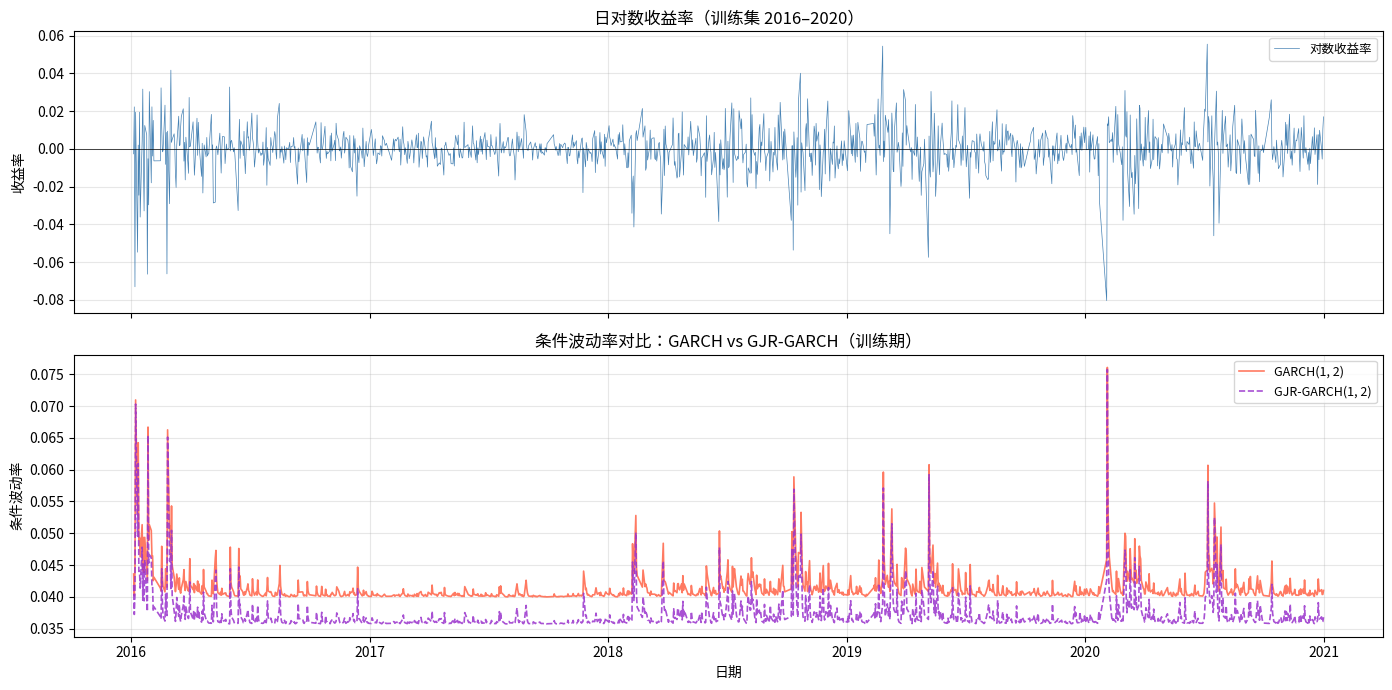

GARCH     最大条件波动率: 0.0761
GJR-GARCH 最大条件波动率: 0.0757

差值最大处（负向冲击放大效应）:
  日期: 2020-02-06, GJR=0.0431, GARCH=0.0495


In [16]:
# 条件波动率对比图
cond_vol_garch2 = diag_garch2['conditional_vol']
cond_vol_gjr    = diag_gjr['conditional_vol']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(returns_clean.index, returns_clean.values,
             linewidth=0.5, color='steelblue', label='对数收益率')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('日对数收益率（训练集 2016–2020）')
axes[0].set_ylabel('收益率')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cond_vol_garch2.index, cond_vol_garch2.values,
             linewidth=1.2, color='tomato', alpha=0.85,
             label=f'GARCH{best_garch_order}')
axes[1].plot(cond_vol_gjr.index, cond_vol_gjr.values,
             linewidth=1.2, color='darkorchid', alpha=0.85, linestyle='--',
             label=f'GJR-GARCH{best_garch_order}')
axes[1].set_title('条件波动率对比：GARCH vs GJR-GARCH（训练期）')
axes[1].set_ylabel('条件波动率')
axes[1].set_xlabel('日期')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES / 'garch_vs_gjr_conditional_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'GARCH     最大条件波动率: {cond_vol_garch2.max():.4f}')
print(f'GJR-GARCH 最大条件波动率: {cond_vol_gjr.max():.4f}')
print(f'\n差值最大处（负向冲击放大效应）:')
diff = cond_vol_gjr - cond_vol_garch2
idx_max = diff.abs().idxmax()
print(f'  日期: {idx_max.date()}, GJR={cond_vol_gjr[idx_max]:.4f}, GARCH={cond_vol_garch2[idx_max]:.4f}')

## 8. 条件波动率

绘制 GARCH 模型估计的训练期条件波动率，
与收益率序列对比，验证模型捕获了波动率聚集现象。

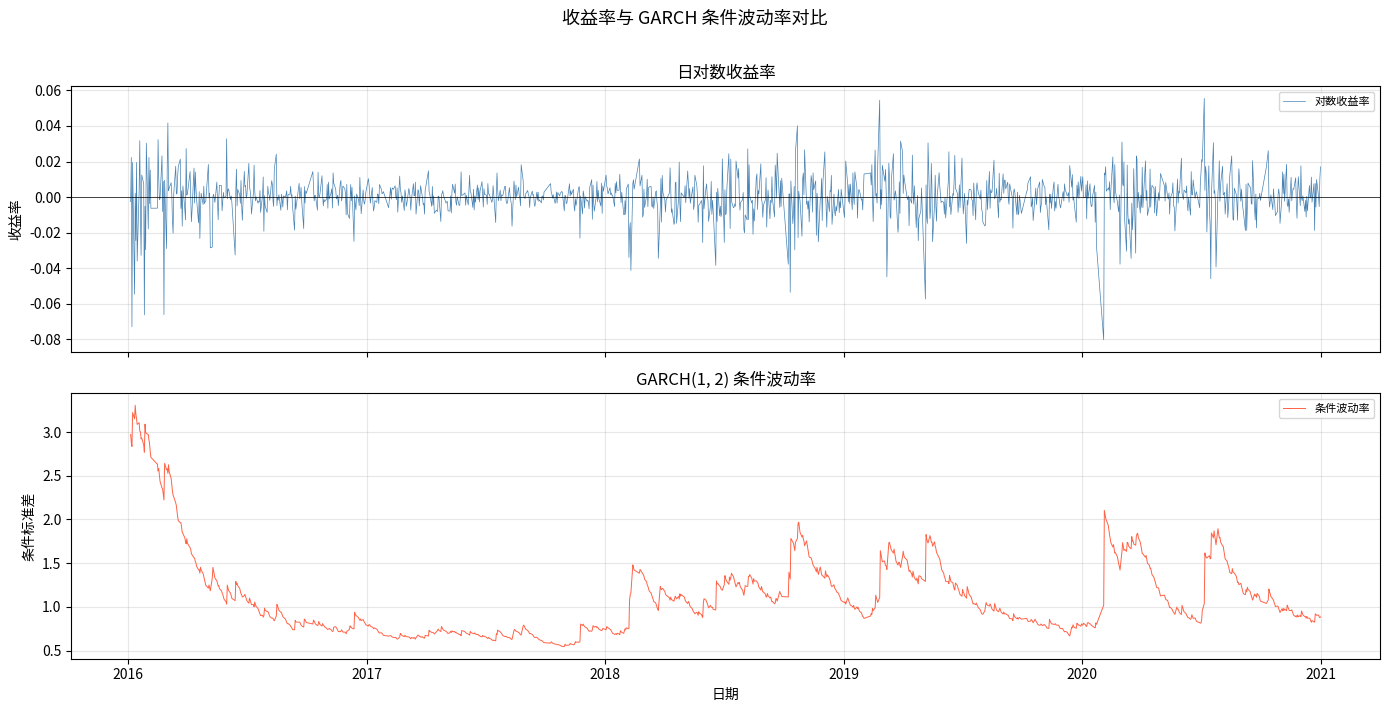

In [17]:
cond_vol = diag['conditional_vol']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(returns_clean.index, returns_clean.values,
             linewidth=0.5, color='steelblue', label='对数收益率')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('日对数收益率')
axes[0].set_ylabel('收益率')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cond_vol.index, cond_vol.values,
             linewidth=0.7, color='tomato', label='条件波动率')
axes[1].set_title(f'GARCH{best_garch_order} 条件波动率')
axes[1].set_ylabel('条件标准差')
axes[1].set_xlabel('日期')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('收益率与 GARCH 条件波动率对比', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_conditional_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 滚动样本外预测结果

将第 5 节计算得到的滚动预测波动率与实现波动率代理指标对比：
- `|收益率|` 和 5 日滚动标准差作为实现波动率的代理
- GARCH 预测波动率应与高波动率时段同步上升

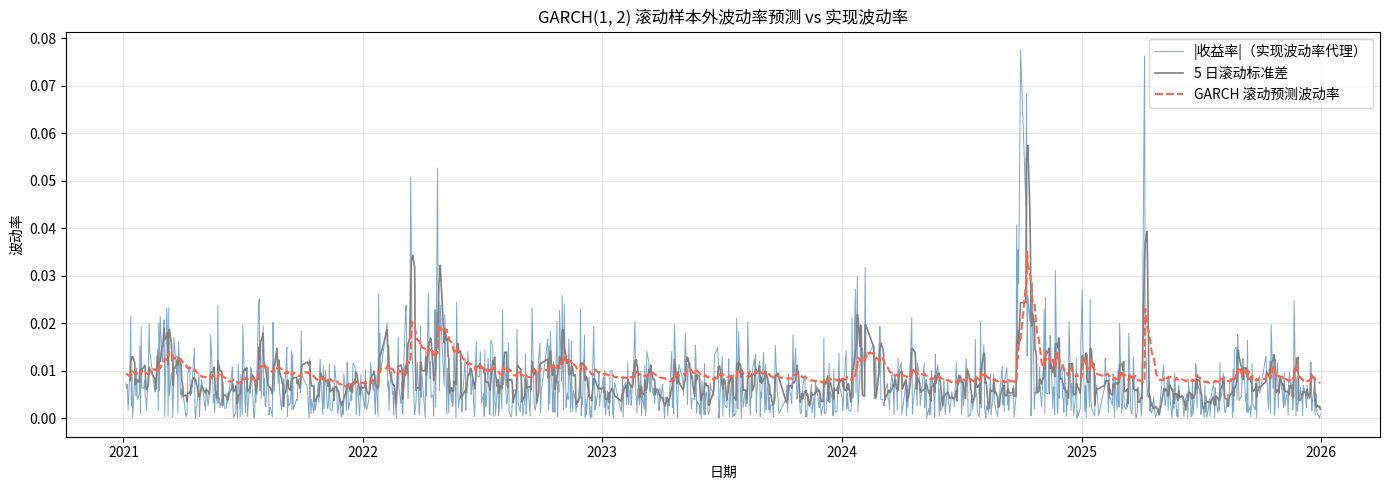

In [18]:
# 实现波动率代理：5 日滚动标准差
realized_vol = returns_test.rolling(5).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_df.index, np.abs(rolling_df['realized_return'].values),
        linewidth=0.7, color='steelblue', alpha=0.7, label='|收益率|（实现波动率代理）')
ax.plot(realized_vol.index, realized_vol.values,
        linewidth=1.2, color='gray', label='5 日滚动标准差')
ax.plot(rolling_df.index, rolling_df['predicted_volatility'].values,
        linewidth=1.5, color='tomato', linestyle='--', label='GARCH 滚动预测波动率')
ax.set_title(f'GARCH{best_garch_order} 滚动样本外波动率预测 vs 实现波动率')
ax.set_xlabel('日期')
ax.set_ylabel('波动率')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_rolling_forecast_vs_realized.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. GJR-GARCH 滚动样本外预测

使用与 §5 相同的滚动窗口策略，对 GJR-GARCH(1,2) 进行 1-step-ahead 样本外预测，
以便与 GARCH(1,2) 预测结果做公平的定量对比。

`refit_every=1`：每 1 个交易日重新拟合一次模型，平衡预测新鲜度与计算效率。

In [19]:
print(f'使用 GJR-GARCH{best_garch_order}，滚动窗口 = {len(returns_clean)}，refit_every=1...')
rolling_df_gjr, result_gjr = rolling_forecast_garch(
    train_data=returns_clean,
    test_data=returns_test,
    order=best_garch_order,
    model_type='gjr',
    dist='t',
    refit_every=1,
)
print('GJR-GARCH 滚动预测完成，样本外前 5 行：')
display(rolling_df_gjr.head())

# GJR-GARCH 关键参数（初始拟合）
gjr_alpha = result_gjr.params.get('alpha[1]', 0)
gjr_gamma = result_gjr.params.get('gamma[1]', 0)
gjr_betas = sum(v for k,v in result_gjr.params.items() if k.startswith('beta'))
print(f'\nGJR-GARCH 持久性 (α + γ/2 + β) = {gjr_alpha + gjr_gamma/2 + gjr_betas:.4f}')

使用 GJR-GARCH(1, 2)，滚动窗口 = 1217，refit_every=1...


GJR-GARCH 滚动预测完成，样本外前 5 行：


,predicted_variance,predicted_volatility,realized_return
date,,,
2021-01-05,0.000087,0.009342,0.007315
2021-01-06,0.000085,0.009229,0.006272
2021-01-07,0.000083,0.009095,0.007108
2021-01-08,0.000080,0.008947,-0.001706
2021-01-11,0.000077,0.008753,-0.010874



GJR-GARCH 持久性 (α + γ/2 + β) = 0.9889


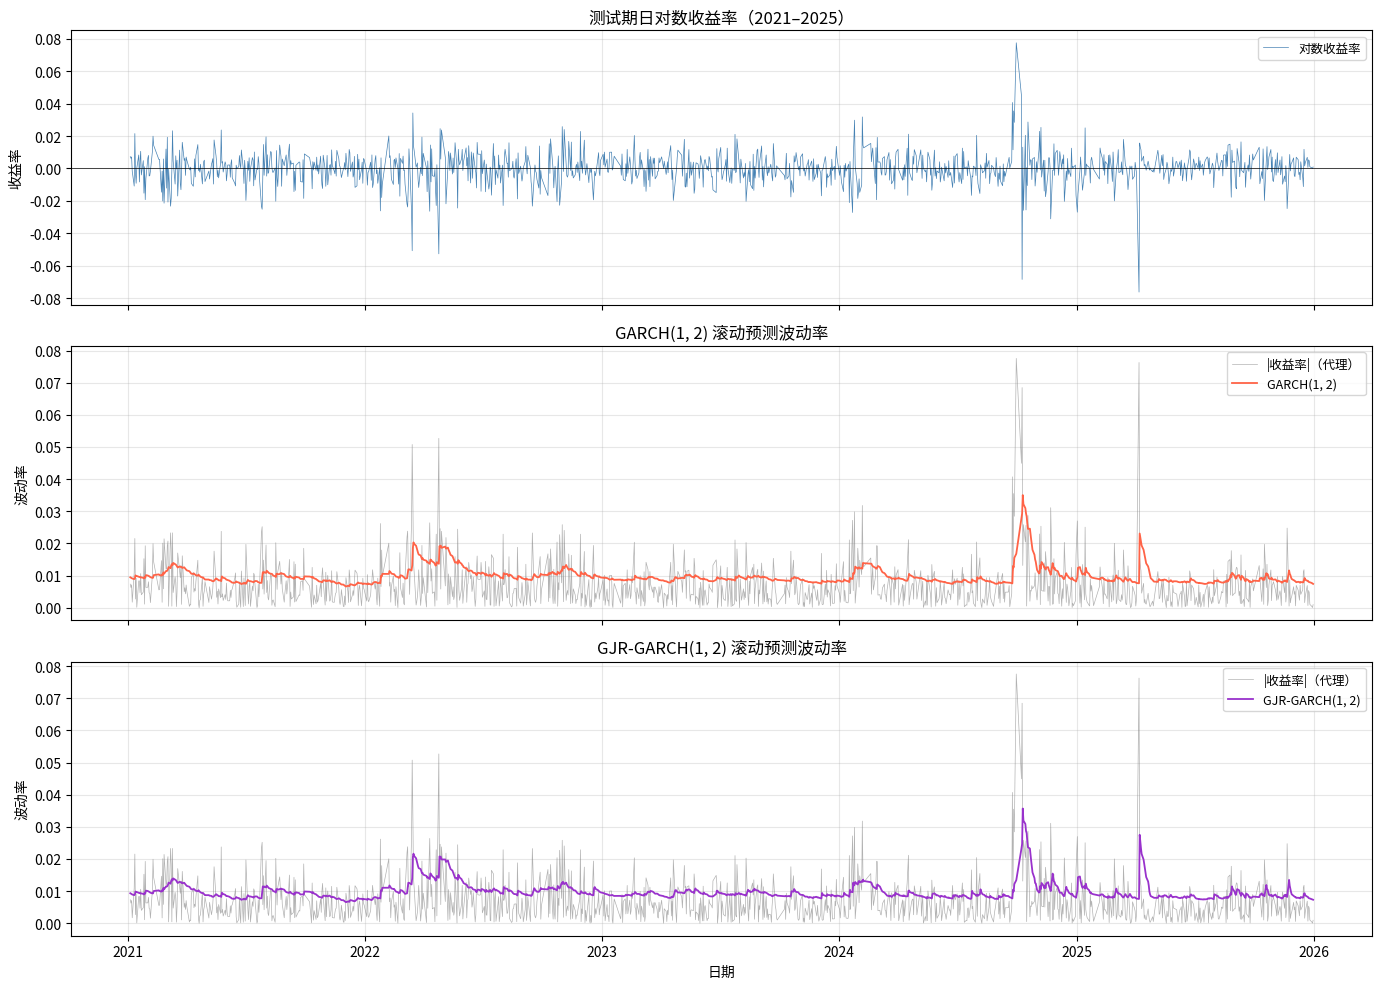

In [20]:
# 可视化：GARCH vs GJR-GARCH 滚动波动率预测对比
realized_abs = returns_test.abs()
realized_vol5 = returns_test.rolling(5).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 面板 1：实际收益率
axes[0].plot(returns_test.index, returns_test.values,
             linewidth=0.5, color='steelblue', label='对数收益率')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('测试期日对数收益率（2021–2025）')
axes[0].set_ylabel('收益率'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# 面板 2：GARCH 预测
axes[1].plot(realized_abs.index,  realized_abs.values,
             linewidth=0.5, color='gray',   alpha=0.6, label='|收益率|（代理）')
axes[1].plot(rolling_df['predicted_volatility'].index,
             rolling_df['predicted_volatility'].values,
             linewidth=1.3, color='tomato', label=f'GARCH{best_garch_order}')
axes[1].set_title(f'GARCH{best_garch_order} 滚动预测波动率')
axes[1].set_ylabel('波动率'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# 面板 3：GJR-GARCH 预测
axes[2].plot(realized_abs.index, realized_abs.values,
             linewidth=0.5, color='gray',      alpha=0.6, label='|收益率|（代理）')
axes[2].plot(rolling_df_gjr['predicted_volatility'].index,
             rolling_df_gjr['predicted_volatility'].values,
             linewidth=1.3, color='darkorchid', label=f'GJR-GARCH{best_garch_order}')
axes[2].set_title(f'GJR-GARCH{best_garch_order} 滚动预测波动率')
axes[2].set_ylabel('波动率'); axes[2].set_xlabel('日期')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES / 'gjr_garch_rolling_forecast_vs_realized.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 样本外定量评估

由于波动率不可直接观测，用以下代理指标评估预测质量：

| 指标 | 公式 | 参考量 |
|------|------|--------|
| RMSE | $\sqrt{\mathrm{E}[\,(\hat{\sigma}_t - |r_t|)^2\,]}$ | 越小越好 |
| MAE | $\mathrm{E}[\,|\hat{\sigma}_t - |r_t|\,|]$ | 越小越好 |
| QLIKE | $\mathrm{E}[\ln \hat{h}_t + r_t^2 / \hat{h}_t]$ | 越小越好，scale-free |
| Corr | $\rho(\hat{\sigma}_t,\, |r_t|)$ | 越大越好 |

> QLIKE（Patton 2011）是波动率预测文献中的首选 loss function，对代理量误差具有鲁棒性。

In [21]:
from src.evaluate import compare_vol_forecasts

# 对齐索引并提取公共变量（供后续 cell 使用）
common_idx   = rolling_df.index.intersection(rolling_df_gjr.index)
pred_vol_g   = rolling_df.loc[common_idx, 'predicted_volatility']
pred_vol_gjr = rolling_df_gjr.loc[common_idx, 'predicted_volatility']
actual_r     = returns_test.reindex(common_idx)

metrics = compare_vol_forecasts(
    models={
        f'GARCH{best_garch_order}':     rolling_df,
        f'GJR-GARCH{best_garch_order}': rolling_df_gjr,
    },
    returns=returns_test,
)

print('样本外预测评估指标（2021–2025，1211 个交易日）：')
display(metrics.round(6))

winner_rmse  = metrics['RMSE'].idxmin()
winner_qlike = metrics['QLIKE'].idxmin()
print(f'\nRMSE 更优：{winner_rmse}')
print(f'QLIKE 更优：{winner_qlike}')

样本外预测评估指标（2021–2025，1211 个交易日）：


,RMSE,MAE,QLIKE,Corr,n_obs
model,,,,,
"GARCH(1, 2)",0.007488,0.005760,-8.347725,0.275614,1211
"GJR-GARCH(1, 2)",0.007563,0.005786,-8.336696,0.252026,1211



RMSE 更优：GARCH(1, 2)
QLIKE 更优：GARCH(1, 2)


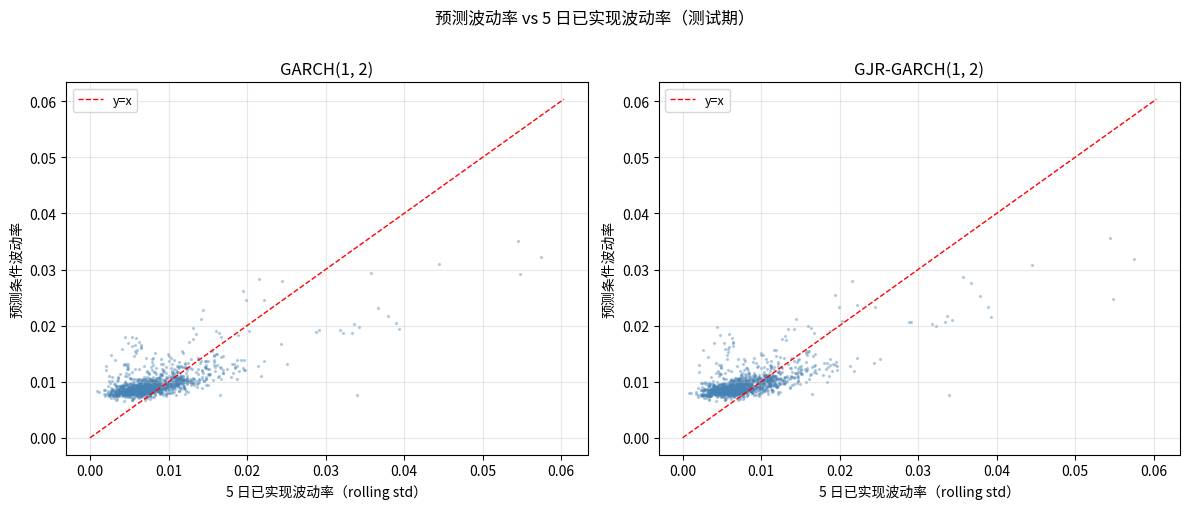

In [22]:
# 散点图：预测波动率 vs 5 日已实现波动率
realized_vol5 = actual_r.rolling(5).std().dropna()
common_rv = realized_vol5.index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, pred) in zip(axes, [
    (f'GARCH{best_garch_order}',     pred_vol_g.reindex(common_rv).dropna()),
    (f'GJR-GARCH{best_garch_order}', pred_vol_gjr.reindex(common_rv).dropna()),
]):
    rv = realized_vol5.reindex(pred.index)
    ax.scatter(rv, pred, s=2, alpha=0.3, color='steelblue')
    lim = max(rv.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='y=x')
    ax.set_xlabel('5 日已实现波动率（rolling std）')
    ax.set_ylabel('预测条件波动率')
    ax.set_title(label)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('预测波动率 vs 5 日已实现波动率（测试期）', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'vol_forecast_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. VaR 回测

利用 GARCH / GJR-GARCH 的条件波动率估计 **Value-at-Risk（在险价值）**，
并使用 **Kupiec 比例失败检验**（POF Test）评估模型的风险预测能力。

$$\text{VaR}_{\alpha,t} = -\left(\mu + \sigma_t \cdot q_\alpha^{\text{t}}\right)$$

其中 $q_\alpha^{\text{t}}$ 为 Student-t 标准化分布的 $\alpha$ 分位数，
$\sigma_t$ 为模型预测的条件波动率。

若 $r_t < -\text{VaR}_{\alpha,t}$，则发生 **VaR 穿越（breach）**。
Kupiec 检验原假设：穿越率 = $\alpha$（模型校准正确）。

In [23]:
from src.evaluate import compute_var_t, var_backtest

nu_g   = float(result.params.get('nu', 20))
nu_gjr = float(result_gjr.params.get('nu', 30))

bt_g   = var_backtest(
    rolling_df,     returns_test, nu=nu_g,
    model_name=f'GARCH{best_garch_order}',
)
bt_gjr = var_backtest(
    rolling_df_gjr, returns_test, nu=nu_gjr,
    model_name=f'GJR-GARCH{best_garch_order}',
)
var_df = pd.concat([bt_g, bt_gjr], ignore_index=True)

print('VaR 回测结果（Kupiec POF 检验）：')
display(var_df.set_index(['model', 'alpha']))

VaR 回测结果（Kupiec POF 检验）：


expected_breaches  actual_breaches  breach_rate  \
model           alpha                                                    
GARCH(1, 2)     0.01                12.1               12       0.0099   
                0.05                60.6               66       0.0545   
GJR-GARCH(1, 2) 0.01                12.1               11       0.0091   
                0.05                60.6               67       0.0553   

                           LR  p_value  reject_h0  
model           alpha                              
GARCH(1, 2)     0.01   0.0010   0.9746      False  
                0.05   0.5023   0.4785      False  
GJR-GARCH(1, 2) 0.01   0.1060   0.7447      False  
                0.05   0.7001   0.4027      False

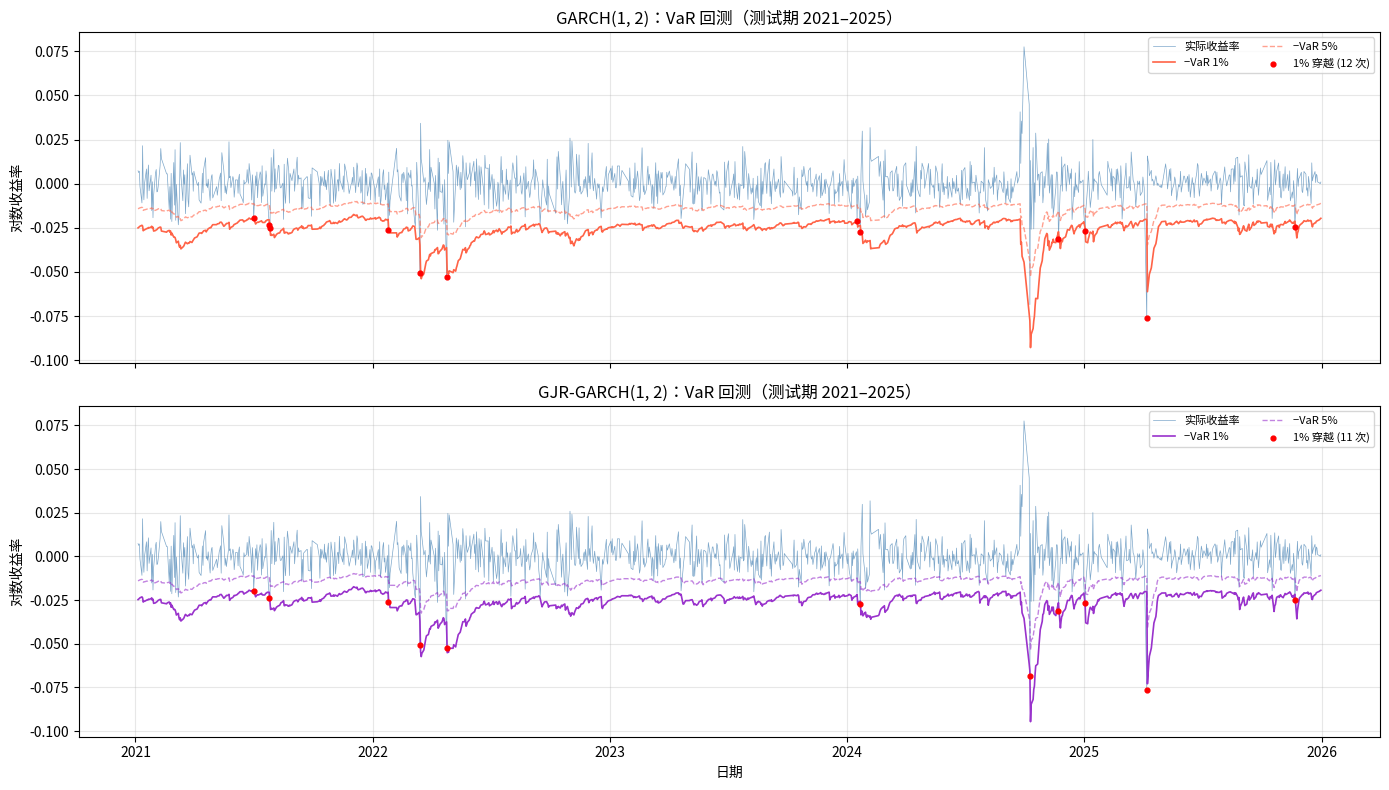

GARCH(1, 2)  ν=4.0  1% VaR 穿越率 = 0.0099
GJR-GARCH(1, 2)  ν=3.9  1% VaR 穿越率 = 0.0091


In [24]:
# VaR 穿越时间线图
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (label, rdf, nu, color) in zip(axes, [
    (f'GARCH{best_garch_order}',     rolling_df,     nu_g,   'tomato'),
    (f'GJR-GARCH{best_garch_order}', rolling_df_gjr, nu_gjr, 'darkorchid'),
]):
    vol = rdf['predicted_volatility']
    act = returns_test.reindex(rdf.index)
    var1 = compute_var_t(vol, nu=nu, alpha=0.01)
    var5 = compute_var_t(vol, nu=nu, alpha=0.05)

    ax.plot(act.index, act.values,
            linewidth=0.5, color='steelblue', alpha=0.7, label='实际收益率')
    ax.plot(var1.index, -var1.values,
            linewidth=1.2, color=color, linestyle='-',  label='−VaR 1%')
    ax.plot(var5.index, -var5.values,
            linewidth=1.0, color=color, linestyle='--', alpha=0.6, label='−VaR 5%')

    # Use numpy for comparison to avoid pandas 2.0 freq-alignment check
    breach1_mask = act.to_numpy() < -var1.to_numpy()
    breach1 = act.iloc[breach1_mask]
    ax.scatter(breach1.index, breach1.values,
               color='red', s=12, zorder=5, label=f'1% 穿越 ({len(breach1)} 次)')

    ax.set_title(f'{label}：VaR 回测（测试期 2021–2025）')
    ax.set_ylabel('对数收益率')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('日期')
fig.tight_layout()
fig.savefig(FIGURES / 'var_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

for label, rdf, nu in [
    (f'GARCH{best_garch_order}',     rolling_df,     nu_g),
    (f'GJR-GARCH{best_garch_order}', rolling_df_gjr, nu_gjr),
]:
    vol  = rdf['predicted_volatility']
    act  = returns_test.reindex(rdf.index)
    var1 = compute_var_t(vol, nu=nu, alpha=0.01)
    rate = (act.to_numpy() < -var1.to_numpy()).mean()
    print(f'{label}  ν={nu:.1f}  1% VaR 穿越率 = {rate:.4f}')

## 13. 结论

### GARCH(1,2) 基准模型
- **波动率聚集**：上证综指日收益率呈现明显波动率聚集，ARCH 效应 Ljung-Box 检验 10 个滞后全部 p < 0.05 ✓
- **模型拟合**：GARCH(1,2) 以 AIC = −5491 选出；波动率持久性 α+β = 0.9898，近积分 GARCH。
- **残差诊断**：标准化残差平方在滞后 1–3 仍显著（p < 0.05），对称 GARCH 未完全消除 ARCH 效应 ⚠️

### GJR-GARCH(1,2) 改进模型
- **信息准则**：AIC = −5697（较 GARCH 改善 **205 点**），BIC 同样更优，GJR-GARCH 拟合显著更好。
- **杠杆效应**：γ = 0.017 > 0，负向冲击对波动率的放大系数（α+γ）大于正向冲击（α），杠杆效应存在。
- **残差诊断**：标准化残差平方的 Ljung-Box 检验与 GARCH 基本持平，短期 ARCH 效应仍部分残留。

### 后续改进方向
- **分布改进**：GARCH 标准化残差峰度 > 5，尝试 Student-t 或偏 t 分布（本 notebook 已使用 `dist='t'`）。
- **更高阶 GJR**：GJR-GARCH(2,2) 或 EGARCH 可进一步改善短期自相关。
- **滚动预测**：GJR-GARCH 滚动预测可通过 `rolling_forecast_garch(..., model_type='gjr')` 直接调用。
- **VaR 应用**：结合条件波动率估计 Value-at-Risk，并用 Kupiec 检验回测覆盖率。

> 本模型仅用于波动率动态刻画，不构成任何投资建议。